# 06 — EfficientNetV2 Model Analysis (Updated)

This notebook uses the **same test split and image preprocessing logic as the completed EfficientNetV2 training notebook** and loads only the fine-tuned checkpoint.

Run the cells **from top to bottom**.

Outputs are saved under:
`reports/model_analysis/`


In [1]:
# STEP 1 — Imports

from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [2]:
# STEP 2 — Project paths

PROJECT_ROOT = Path(r"D:/Practice Projects/Disease Detection")

SPLIT_DIR = PROJECT_ROOT / "preprocessing" / "splits"
MODEL_DIR = PROJECT_ROOT / "model"
REPORT_DIR = PROJECT_ROOT / "reports" / "model_analysis"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV = SPLIT_DIR / "validation.csv"
TEST_CSV = SPLIT_DIR / "test.csv"

FINETUNED_MODEL_PATH = MODEL_DIR / "efficientnetv2_finetuned_best.keras"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TEST_CSV:", TEST_CSV)
print("MODEL:", FINETUNED_MODEL_PATH)


PROJECT_ROOT: D:\Practice Projects\Disease Detection
TEST_CSV: D:\Practice Projects\Disease Detection\preprocessing\splits\test.csv
MODEL: D:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras


In [3]:
# STEP 3 — Load split files

if not TEST_CSV.exists():
    raise FileNotFoundError(f"Test CSV not found: {TEST_CSV}")

test_df = pd.read_csv(TEST_CSV)

print("Test CSV rows:", len(test_df))
print("Columns:", list(test_df.columns))
display(test_df.head())


Test CSV rows: 270
Columns: ['image_path', 'label']


,image_path,label
0,../dataset/Messidor-2+EyePac_Balanced\3\200604...,3
1,../dataset/Messidor-2+EyePac_Balanced\0\200511...,0
2,../dataset/Messidor-2+EyePac_Balanced\1\200512...,1
3,../dataset/Messidor-2+EyePac_Balanced\1\200604...,1
4,../dataset/Messidor-2+EyePac_Balanced\0\200604...,0


In [4]:
# STEP 4 — Detect image-path and label columns

def find_column(df, candidates):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None

IMAGE_COL = find_column(
    test_df,
    ["image_path", "filepath", "file_path", "path", "image", "filename"]
)

LABEL_COL = find_column(
    test_df,
    ["label", "class", "class_id", "target", "disease", "y"]
)

if IMAGE_COL is None or LABEL_COL is None:
    raise ValueError(
        f"Could not detect required columns. Found columns: {list(test_df.columns)}"
    )

print("Image column:", IMAGE_COL)
print("Label column:", LABEL_COL)


Image column: image_path
Label column: label


In [5]:
# STEP 5 — Resolve image paths and labels exactly once

def resolve_image_path(value):
    p = Path(str(value))
    if p.is_absolute() and p.exists():
        return p

    # Try relative to project root
    p2 = PROJECT_ROOT / str(value)
    if p2.exists():
        return p2

    # Try common dataset location
    p3 = PROJECT_ROOT / "dataset" / str(value)
    if p3.exists():
        return p3

    return p2

analysis_df = test_df.copy()
analysis_df["resolved_image_path"] = analysis_df[IMAGE_COL].apply(resolve_image_path)

# Convert labels safely to integer class IDs
def to_class_id(v):
    s = str(v).strip()
    if s.lower().startswith("class "):
        s = s[6:]
    try:
        return int(float(s))
    except Exception:
        return None

analysis_df["true_class"] = analysis_df[LABEL_COL].apply(to_class_id)

if analysis_df["true_class"].isna().any():
    raise ValueError("Some test labels could not be converted to class IDs.")

missing = ~analysis_df["resolved_image_path"].apply(lambda p: Path(p).exists())
print("Total test images:", len(analysis_df))
print("Missing image files:", int(missing.sum()))

if missing.any():
    display(analysis_df.loc[missing, [IMAGE_COL, "resolved_image_path", "true_class"]].head(10))
    raise FileNotFoundError("Some test image files were not found.")

print("\nClass distribution:")
print(analysis_df["true_class"].value_counts().sort_index())


Total test images: 270
Missing image files: 0

Class distribution:
true_class
0    54
1    54
2    54
3    54
4    54
Name: count, dtype: int64


In [6]:
# STEP 6 — Load the correct fine-tuned model

if not FINETUNED_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Fine-tuned checkpoint not found:\n{FINETUNED_MODEL_PATH}"
    )

final_model = keras.models.load_model(FINETUNED_MODEL_PATH)

print("Loaded model:", FINETUNED_MODEL_PATH)
print("Input shape:", final_model.input_shape)
print("Output shape:", final_model.output_shape)


Loaded model: D:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
Input shape: (None, 224, 224, 3)
Output shape: (None, 5)


In [7]:
# STEP 7 — Prepare test images
# IMPORTANT: Keep images in 0–255 range.
# EfficientNetV2's built-in preprocessing is used by the model.

IMG_SIZE = (224, 224)
NUM_CLASSES = 5

def load_test_image(path):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    return arr.astype(np.float32)

X_test = np.stack(
    [load_test_image(p) for p in analysis_df["resolved_image_path"]]
)

y_true = analysis_df["true_class"].to_numpy(dtype=int)

print("X_test shape:", X_test.shape)
print("Pixel range:", float(X_test.min()), "to", float(X_test.max()))
print("y_true shape:", y_true.shape)


X_test shape: (270, 224, 224, 3)
Pixel range: 0.0 to 255.0
y_true shape: (270,)


In [8]:
# STEP 8 — Generate predictions

pred_probs = final_model.predict(X_test, batch_size=16, verbose=1)

pred_labels = np.argmax(pred_probs, axis=1)
confidence = np.max(pred_probs, axis=1)

print("Predictions shape:", pred_probs.shape)
print("Total predictions:", len(pred_labels))
print("Prediction class distribution:")
print(pd.Series(pred_labels).value_counts().sort_index())


17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 539ms/step
Predictions shape: (270, 5)
Total predictions: 270
Prediction class distribution:
0     18
1      3
2    151
3     30
4     68
Name: count, dtype: int64


In [9]:
# STEP 9 — Basic accuracy check

accuracy = accuracy_score(y_true, pred_labels)
correct = int(np.sum(y_true == pred_labels))
incorrect = int(np.sum(y_true != pred_labels))

print("Total Test Images:", len(y_true))
print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)
print(f"Overall Accuracy: {accuracy:.4f}")


Total Test Images: 270
Correct Predictions: 128
Incorrect Predictions: 142
Overall Accuracy: 0.4741


In [10]:
# STEP 10 — Classification report

class_names = [f"Class {i}" for i in range(NUM_CLASSES)]

report_dict = classification_report(
    y_true,
    pred_labels,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T

print(classification_report(
    y_true,
    pred_labels,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    zero_division=0,
))

report_df.to_csv(REPORT_DIR / "classification_report.csv")
print("Saved:", REPORT_DIR / "classification_report.csv")


              precision    recall  f1-score   support

     Class 0       0.61      0.20      0.31        54
     Class 1       0.00      0.00      0.00        54
     Class 2       0.33      0.93      0.49        54
     Class 3       0.77      0.43      0.55        54
     Class 4       0.65      0.81      0.72        54

    accuracy                           0.47       270
   macro avg       0.47      0.47      0.41       270
weighted avg       0.47      0.47      0.41       270

Saved: D:\Practice Projects\Disease Detection\reports\model_analysis\classification_report.csv


Confusion Matrix:
[[11  2 41  0  0]
 [ 6  0 47  0  1]
 [ 1  1 50  1  1]
 [ 0  0  9 23 22]
 [ 0  0  4  6 44]]


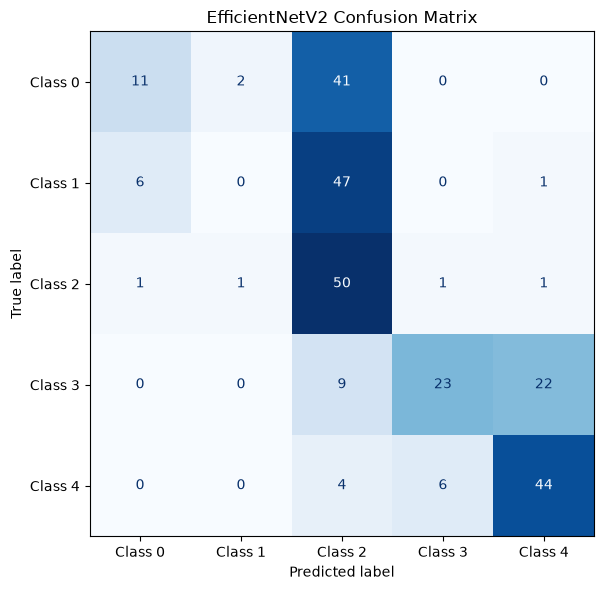

Saved confusion matrix files.


In [11]:
# STEP 11 — Confusion matrix

cm = confusion_matrix(
    y_true,
    pred_labels,
    labels=list(range(NUM_CLASSES))
)

print("Confusion Matrix:")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(REPORT_DIR / "confusion_matrix.csv")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("EfficientNetV2 Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=200)
plt.show()
plt.close()

print("Saved confusion matrix files.")


In [12]:
# STEP 12 — Per-class error analysis

rows = []

for cls in range(NUM_CLASSES):
    total = int(np.sum(y_true == cls))
    correct_cls = int(np.sum((y_true == cls) & (pred_labels == cls)))
    errors_cls = total - correct_cls

    rows.append({
        "class": f"Class {cls}",
        "total": total,
        "correct": correct_cls,
        "errors": errors_cls,
        "accuracy": correct_cls / total if total else 0.0,
    })

class_error_df = pd.DataFrame(rows)

display(class_error_df)

class_error_df.to_csv(
    REPORT_DIR / "per_class_error_analysis.csv",
    index=False
)


,class,total,correct,errors,accuracy
0,Class 0,54,11,43,0.203704
1,Class 1,54,0,54,0.000000
2,Class 2,54,50,4,0.925926
3,Class 3,54,23,31,0.425926
4,Class 4,54,44,10,0.814815


In [13]:
# STEP 13 — Misclassification analysis

mis_rows = []

for true_cls in range(NUM_CLASSES):
    for pred_cls in range(NUM_CLASSES):
        if true_cls == pred_cls:
            continue

        count = int(np.sum(
            (y_true == true_cls) &
            (pred_labels == pred_cls)
        ))

        if count > 0:
            mis_rows.append({
                "true_class": true_cls,
                "predicted_class": pred_cls,
                "count": count,
            })

mis_df = pd.DataFrame(mis_rows).sort_values(
    "count",
    ascending=False
)

display(mis_df)

mis_df.to_csv(
    REPORT_DIR / "misclassification_analysis.csv",
    index=False
)


,true_class,predicted_class,count
3,1,2,47
1,0,2,41
10,3,4,22
9,3,2,9
2,1,0,6
12,4,3,6
11,4,2,4
0,0,1,2
4,1,4,1
8,2,4,1


In [14]:
# STEP 14 — Complete prediction table

prediction_df = pd.DataFrame({
    "image_path": analysis_df[IMAGE_COL].astype(str),
    "true_class": y_true,
    "predicted_class": pred_labels,
    "confidence": confidence,
    "correct": y_true == pred_labels,
})

for cls in range(NUM_CLASSES):
    prediction_df[f"prob_class_{cls}"] = pred_probs[:, cls]

prediction_csv = REPORT_DIR / "test_predictions.csv"
prediction_df.to_csv(prediction_csv, index=False)

print("Prediction report saved:")
print(prediction_csv)

display(prediction_df.head(10))


Prediction report saved:
D:\Practice Projects\Disease Detection\reports\model_analysis\test_predictions.csv


,image_path,true_class,predicted_class,confidence,correct,prob_class_0,prob_class_1,prob_class_2,prob_class_3,prob_class_4
0,../dataset/Messidor-2+EyePac_Balanced\3\200604...,3,2,0.732973,False,0.018875,0.017978,0.732973,0.108539,0.121634
1,../dataset/Messidor-2+EyePac_Balanced\0\200511...,0,0,0.657423,True,0.657423,0.144538,0.195649,0.000633,0.001758
2,../dataset/Messidor-2+EyePac_Balanced\1\200512...,1,2,0.882816,False,0.018217,0.054063,0.882816,0.028855,0.016049
3,../dataset/Messidor-2+EyePac_Balanced\1\200604...,1,0,0.584742,False,0.584742,0.138301,0.267552,0.004482,0.004923
4,../dataset/Messidor-2+EyePac_Balanced\0\200604...,0,0,0.580757,True,0.580757,0.185991,0.224211,0.004439,0.004603
5,../dataset/Messidor-2+EyePac_Balanced\2\200511...,2,2,0.621519,True,0.255045,0.117867,0.621519,0.000433,0.005137
6,../dataset/Messidor-2+EyePac_Balanced\1\200604...,1,2,0.672180,False,0.168793,0.148545,0.672180,0.002855,0.007626
7,../dataset/Messidor-2+EyePac_Balanced\0\200604...,0,2,0.734520,False,0.237924,0.022122,0.734520,0.001401,0.004034
8,../dataset/Messidor-2+EyePac_Balanced\4\25741_...,4,4,0.731118,True,0.000017,0.000017,0.003981,0.264868,0.731118
9,../dataset/Messidor-2+EyePac_Balanced\2\200604...,2,2,0.510639,True,0.317234,0.138012,0.510639,0.006722,0.027392


In [15]:
# STEP 15 — Confidence analysis

print("Highest Confidence:")
high_idx = int(np.argmax(confidence))
print("Image:", prediction_df.loc[high_idx, "image_path"])
print("True Class:", int(prediction_df.loc[high_idx, "true_class"]))
print("Predicted Class:", int(prediction_df.loc[high_idx, "predicted_class"]))
print("Confidence:", f"{confidence[high_idx] * 100:.2f}%")

print("\nLowest Confidence:")
low_idx = int(np.argmin(confidence))
print("Image:", prediction_df.loc[low_idx, "image_path"])
print("True Class:", int(prediction_df.loc[low_idx, "true_class"]))
print("Predicted Class:", int(prediction_df.loc[low_idx, "predicted_class"]))
print("Confidence:", f"{confidence[low_idx] * 100:.2f}%")

print("\nAverage Confidence:", f"{confidence.mean() * 100:.2f}%")


Highest Confidence:
Image: ../dataset/Messidor-2+EyePac_Balanced\4\13651_right - Copy.jpeg
True Class: 4
Predicted Class: 4
Confidence: 99.99%

Lowest Confidence:
Image: ../dataset/Messidor-2+EyePac_Balanced\3\33840_left.jpeg
True Class: 3
Predicted Class: 4
Confidence: 36.71%

Average Confidence: 75.29%


In [16]:
# STEP 16 — Correct vs incorrect confidence

correct_conf = confidence[y_true == pred_labels]
incorrect_conf = confidence[y_true != pred_labels]

print("Correct predictions:", len(correct_conf))
print("Incorrect predictions:", len(incorrect_conf))

if len(correct_conf):
    print("Average correct confidence:", f"{correct_conf.mean() * 100:.2f}%")

if len(incorrect_conf):
    print("Average incorrect confidence:", f"{incorrect_conf.mean() * 100:.2f}%")


Correct predictions: 128
Incorrect predictions: 142
Average correct confidence: 80.40%
Average incorrect confidence: 70.68%


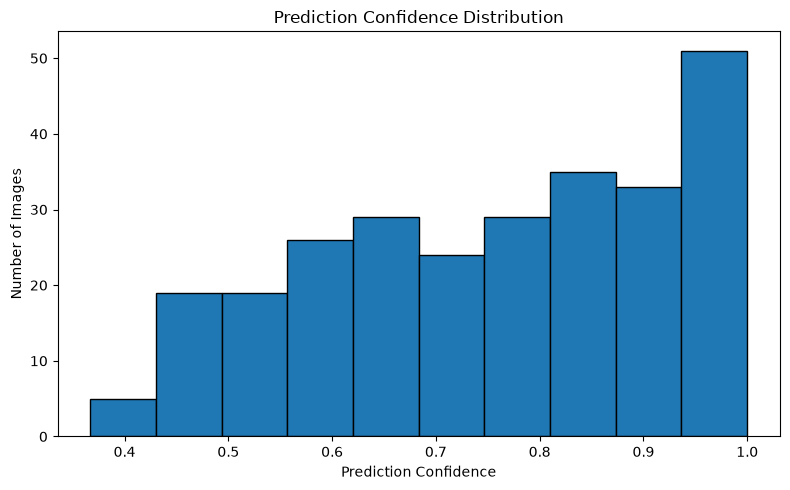

In [17]:
# STEP 17 — Confidence distribution

plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=10, edgecolor="black")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")
plt.title("Prediction Confidence Distribution")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confidence_distribution.png", dpi=200)
plt.show()
plt.close()


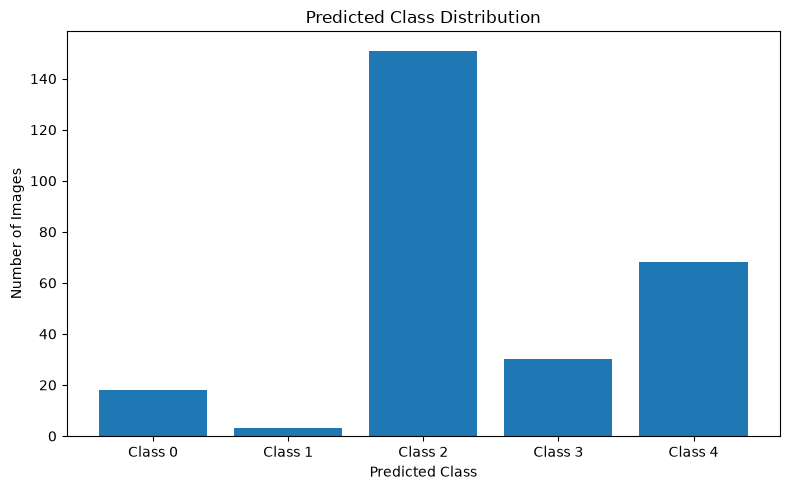

0     18
1      3
2    151
3     30
4     68
Name: count, dtype: int64


In [18]:
# STEP 18 — Predicted class distribution

pred_counts = pd.Series(pred_labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    [f"Class {i}" for i in pred_counts.index],
    pred_counts.values
)
plt.xlabel("Predicted Class")
plt.ylabel("Number of Images")
plt.title("Predicted Class Distribution")
plt.tight_layout()
plt.savefig(REPORT_DIR / "predicted_class_distribution.png", dpi=200)
plt.show()
plt.close()

print(pred_counts)


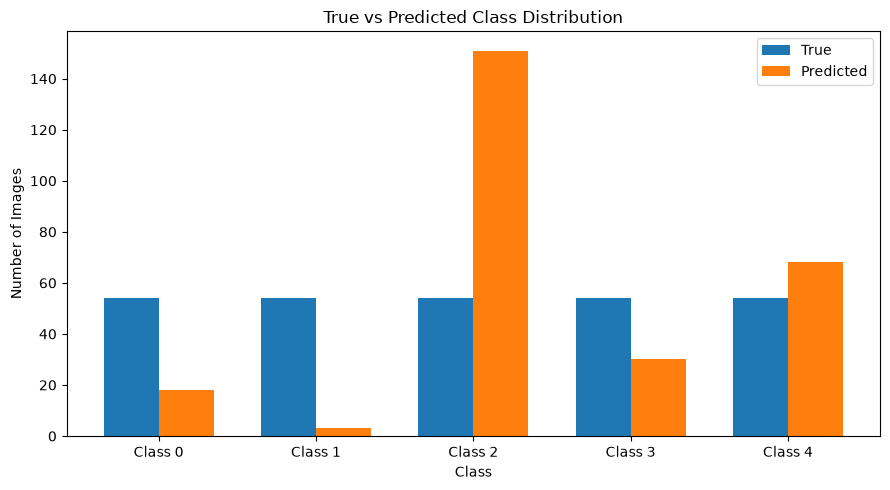

In [19]:
# STEP 19 — True vs predicted distribution

true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(pred_labels).value_counts().sort_index()

x = np.arange(NUM_CLASSES)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(
    x - width / 2,
    [true_counts.get(i, 0) for i in range(NUM_CLASSES)],
    width,
    label="True"
)
plt.bar(
    x + width / 2,
    [pred_counts.get(i, 0) for i in range(NUM_CLASSES)],
    width,
    label="Predicted"
)

plt.xticks(x, class_names)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("True vs Predicted Class Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "true_vs_predicted_distribution.png", dpi=200)
plt.show()
plt.close()


In [20]:
# STEP 20 — Lowest-confidence predictions

lowest_df = prediction_df.sort_values(
    "confidence",
    ascending=True
).head(20)

display(
    lowest_df[
        ["image_path", "true_class", "predicted_class", "confidence", "correct"]
    ]
)

lowest_df.to_csv(
    REPORT_DIR / "lowest_confidence_predictions.csv",
    index=False
)


,image_path,true_class,predicted_class,confidence,correct
63,../dataset/Messidor-2+EyePac_Balanced\3\33840_...,3,4,0.367127,False
241,../dataset/Messidor-2+EyePac_Balanced\0\200604...,0,2,0.369831,False
67,../dataset/Messidor-2+EyePac_Balanced\2\200604...,2,4,0.392181,False
227,../dataset/Messidor-2+EyePac_Balanced\0\200604...,0,1,0.393843,False
105,../dataset/Messidor-2+EyePac_Balanced\3\200604...,3,4,0.418535,False
79,../dataset/Messidor-2+EyePac_Balanced\0\200605...,0,1,0.434699,False
183,../dataset/Messidor-2+EyePac_Balanced\0\200605...,0,2,0.436205,False
23,../dataset/Messidor-2+EyePac_Balanced\1\200604...,1,2,0.439650,False
72,../dataset/Messidor-2+EyePac_Balanced\1\200604...,1,0,0.439953,False
184,../dataset/Messidor-2+EyePac_Balanced\3\44200_...,3,4,0.440324,False


In [21]:
# STEP 21 — Most common misclassifications

if len(mis_df):
    print("Most common misclassifications:")
    display(mis_df.head(10))
else:
    print("No misclassifications found.")


Most common misclassifications:


,true_class,predicted_class,count
3,1,2,47
1,0,2,41
10,3,4,22
9,3,2,9
2,1,0,6
12,4,3,6
11,4,2,4
0,0,1,2
4,1,4,1
8,2,4,1


In [22]:
# STEP 22 — Final summary

summary = {
    "total_test_images": len(y_true),
    "correct_predictions": correct,
    "incorrect_predictions": incorrect,
    "overall_accuracy": float(accuracy),
    "average_confidence": float(confidence.mean()),
    "highest_confidence": float(confidence.max()),
    "lowest_confidence": float(confidence.min()),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(
    REPORT_DIR / "model_analysis_summary.csv",
    index=False
)

print("=" * 55)
print("MODEL ANALYSIS COMPLETED")
print("=" * 55)
print("Total test images:", summary["total_test_images"])
print("Correct predictions:", summary["correct_predictions"])
print("Incorrect predictions:", summary["incorrect_predictions"])
print(f"Overall accuracy: {summary['overall_accuracy']:.4f}")
print(f"Average confidence: {summary['average_confidence'] * 100:.2f}%")
print(f"Highest confidence: {summary['highest_confidence'] * 100:.2f}%")
print(f"Lowest confidence: {summary['lowest_confidence'] * 100:.2f}%")
print("\nReports saved to:")
print(REPORT_DIR)


MODEL ANALYSIS COMPLETED
Total test images: 270
Correct predictions: 128
Incorrect predictions: 142
Overall accuracy: 0.4741
Average confidence: 75.29%
Highest confidence: 99.99%
Lowest confidence: 36.71%

Reports saved to:
D:\Practice Projects\Disease Detection\reports\model_analysis
